<a href="https://colab.research.google.com/github/sanmeet1811/Python-Projects/blob/main/Commodity_Forcast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Runs the full commodity analysis pipeline:
  Step 1: Fetch price data
  Step 2: Compute indicators
  Step 3: Forecast prices
  Step 4: Generate charts
  Step 5: Print analyst summary report

In [15]:
import numpy as np

In [30]:
import os
print(os.getcwd())

/content


Loading data from Yahoo Finance directly

In [16]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta
import os

COMMODITIES = {
    'Crude_Oil':   'CL=F',
    'Gold':        'GC=F',
    'Natural_Gas': 'NG=F',
    'Silver':      'SI=F',
    'Wheat':       'ZW=F',
}

save_folder = 'data'
os.makedirs(save_folder, exist_ok=True)

end_date   = datetime.today()
start_date = end_date - timedelta(days=365 * 2)

price_data = {}

for name, ticker in COMMODITIES.items():
    try:
        raw = yf.download(ticker, start=start_date, end=end_date,
                          progress=False, auto_adjust=True)
        if raw.empty:
            print(f"✗ {name} — no data returned")
            continue

        close = raw['Close']

        # Fix: flatten if yfinance returns a DataFrame instead of Series
        if isinstance(close, pd.DataFrame):
            close = close.iloc[:, 0]

        close.name = name
        price_data[name] = close
        print(f"✓ {name}  ({len(close)} rows)")

    except Exception as e:
        print(f"✗ {name} — error: {e}")

# Combine safely
df = pd.concat(price_data.values(), axis=1)
df.columns = price_data.keys()
df = df.ffill().dropna()

# Save
df.to_csv(f"{save_folder}/all_commodities.csv")
print(f"\nShape : {df.shape}")
df.tail(3)

✓ Crude_Oil  (503 rows)
✓ Gold  (503 rows)
✓ Natural_Gas  (503 rows)
✓ Silver  (503 rows)
✓ Wheat  (502 rows)

Shape : (503, 5)


,Crude_Oil,Gold,Natural_Gas,Silver,Wheat
Date,,,,,
2026-05-06,95.080002,4681.899902,2.730,76.810997,606.00
2026-05-07,94.809998,4699.799805,2.769,79.700996,601.75
2026-05-08,95.419998,4720.399902,2.757,80.394997,607.50


In [17]:
!pip install yfinance pandas numpy matplotlib seaborn scikit-learn

#Analysis

In [18]:
def compute_moving_averages(df, short=20, long=50):
    """
    Adds 20-day and 50-day moving averages for every commodity.
    Returns a dictionary: { 'Crude_Oil': DataFrame_with_MAs, ... }
    """
    results = {}

    for col in df.columns:
        series = df[col].dropna()
        temp = pd.DataFrame({'Price': series})
        temp[f'MA_{short}']  = series.rolling(window=short).mean()
        temp[f'MA_{long}']   = series.rolling(window=long).mean()
        temp['Signal'] = np.where(temp[f'MA_{short}'] > temp[f'MA_{long}'], 'Bullish', 'Bearish')
        results[col] = temp

    return results

In [19]:
def compute_daily_returns(df):
    """
    Computes percentage daily returns.
    Returns a DataFrame of returns.
    """
    returns = df.pct_change().dropna()
    returns.columns = [f"{c}_Return" for c in returns.columns]
    return returns


In [20]:
def compute_volatility(df, window=30):
    """
    Computes rolling annualised volatility (std of daily returns).
    Uses 252 trading days convention.
    """
    daily_returns = df.pct_change()
    volatility    = daily_returns.rolling(window=window).std() * np.sqrt(252) * 100
    volatility.columns = [f"{c}_Volatility_%" for c in volatility.columns]
    return volatility.dropna()

In [21]:
def compute_correlation(df):
    """
    Returns the correlation matrix between all commodities.
    """
    daily_returns = df.pct_change().dropna()
    corr_matrix   = daily_returns.corr().round(3)
    return corr_matrix


In [22]:
def print_summary(df):
    """
    Prints a readable summary table for the latest available prices.
    """
    latest = df.iloc[-1]
    prev   = df.iloc[-2]
    returns_today = ((latest - prev) / prev * 100).round(2)

    print(f"  {'Commodity':<18} {'Price':>10}  {'1D Change':>10}")
    for col in df.columns:
        change = returns_today[col]
        arrow  = "up" if change >= 0 else "down"
        print(f"  {col:<18} {latest[col]:>10.2f}  {arrow} {abs(change):>6.2f}%")


In [23]:
print_summary(df)

  Commodity               Price   1D Change
  Crude_Oil               95.42  up   0.64%
  Gold                  4720.40  up   0.44%
  Natural_Gas              2.76  down   0.43%
  Silver                  80.39  up   0.87%
  Wheat                  607.50  up   0.96%


#Forecast
Generates a 30-day price forecast for each commodity
using linear regression on the most recent 60 days of prices.

In [24]:
from sklearn.linear_model import LinearRegression
from datetime import timedelta

In [25]:
from sklearn.linear_model import LinearRegression
import numpy as np
from datetime import timedelta

def forecast_price(series, lookback=60, horizon=30):
    series = series.dropna()

    if len(series) < lookback:
        print(f"  [!] Not enough data for forecast (need {lookback}, got {len(series)})")
        return None

    # ← everything below must be indented INSIDE the function
    recent = series.iloc[-lookback:]          # note: -lookback not lookback
    X = np.arange(len(recent)).reshape(-1, 1)
    y = recent.values

    model = LinearRegression()
    model.fit(X, y)

    y_hat        = model.predict(X)
    residual_std = np.std(y - y_hat)

    future_X     = np.arange(len(recent), len(recent) + horizon).reshape(-1, 1)
    forecast     = model.predict(future_X)

    last_date    = series.index[-1]
    future_dates = [last_date + timedelta(days=i+1) for i in range(horizon)]

    result = pd.DataFrame({
        'Forecast': forecast,
        'Lower':    forecast - residual_std,
        'Upper':    forecast + residual_std,
    }, index=future_dates)

    trend = 'Bullish 📈' if model.coef_[0] > 0 else 'Bearish 📉'

    return result, model.coef_[0], trend

In [26]:
def forecast_all(df, lookback=60, horizon=30):
    """
    Runs forecasts for all commodities and returns a dict of results.
    """
    forecasts = {}


    print(f"  30-Day Price Forecasts (based on last {lookback} trading days)")

    print(f"  {'Commodity':<18} {'Current':>9}  {'30D Forecast':>13}  {'Trend':>12}")


    for col in df.columns:
        out = forecast_price(df[col], lookback=lookback, horizon=horizon)
        if out is None:
            continue

        result_df, slope, trend = out
        current  = df[col].dropna().iloc[-1]
        projected = result_df['Forecast'].iloc[-1]

        print(f"  {col:<18} {current:>9.2f}  {projected:>13.2f}  {trend:>12}")

        forecasts[col] = {
            'data':    result_df,
            'slope':   slope,
            'trend':   trend,
            'current': current,
            'target':  projected,
        }

    return forecasts

In [27]:
forecast_all(df)

  30-Day Price Forecasts (based on last 60 trading days)
  Commodity            Current   30D Forecast         Trend
  Crude_Oil              95.42         125.98     Bullish 📈
  Gold                 4720.40        4263.37     Bearish 📉
  Natural_Gas             2.76           2.38     Bearish 📉
  Silver                 80.39          69.24     Bearish 📉
  Wheat                 607.50         649.56     Bullish 📈


{'Crude_Oil': {'data':               Forecast       Lower       Upper
  2026-05-09  108.224666   99.062024  117.387309
  2026-05-10  108.837060   99.674417  117.999703
  2026-05-11  109.449453  100.286811  118.612096
  2026-05-12  110.061847  100.899204  119.224490
  2026-05-13  110.674240  101.511598  119.836883
  2026-05-14  111.286634  102.123991  120.449276
  2026-05-15  111.899027  102.736384  121.061670
  2026-05-16  112.511421  103.348778  121.674063
  2026-05-17  113.123814  103.961171  122.286457
  2026-05-18  113.736207  104.573565  122.898850
  2026-05-19  114.348601  105.185958  123.511244
  2026-05-20  114.960994  105.798352  124.123637
  2026-05-21  115.573388  106.410745  124.736030
  2026-05-22  116.185781  107.023138  125.348424
  2026-05-23  116.798175  107.635532  125.960817
  2026-05-24  117.410568  108.247925  126.573211
  2026-05-25  118.022962  108.860319  127.185604
  2026-05-26  118.635355  109.472712  127.797998
  2026-05-27  119.247748  110.085106  128.410391

#Dashboard

dashboard.py
Generates 4 publication-quality charts saved as PNG files.
  1. Price + moving averages
  2. Rolling volatility
  3. Correlation heatmap
  4. 30-day price forecast
"""

In [36]:
!pip install yfinance matplotlib seaborn pandas -q

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

In [37]:
tickers = {
    'Crude_Oil':  'CL=F',
    'Gold':       'GC=F',
    'Natural_Gas':'NG=F',
}

end   = datetime.today()
start = end - timedelta(days=365)

df = pd.DataFrame()
for name, ticker in tickers.items():
    raw = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=True)
    df[name] = raw['Close'].squeeze()

df = df.ffill().dropna()
print(df.tail(3))

            Crude_Oil         Gold  Natural_Gas
Date                                           
2026-05-06  95.080002  4681.899902        2.730
2026-05-07  94.809998  4699.799805        2.769
2026-05-08  95.419998  4720.399902        2.757


In [39]:
%matplotlib inline

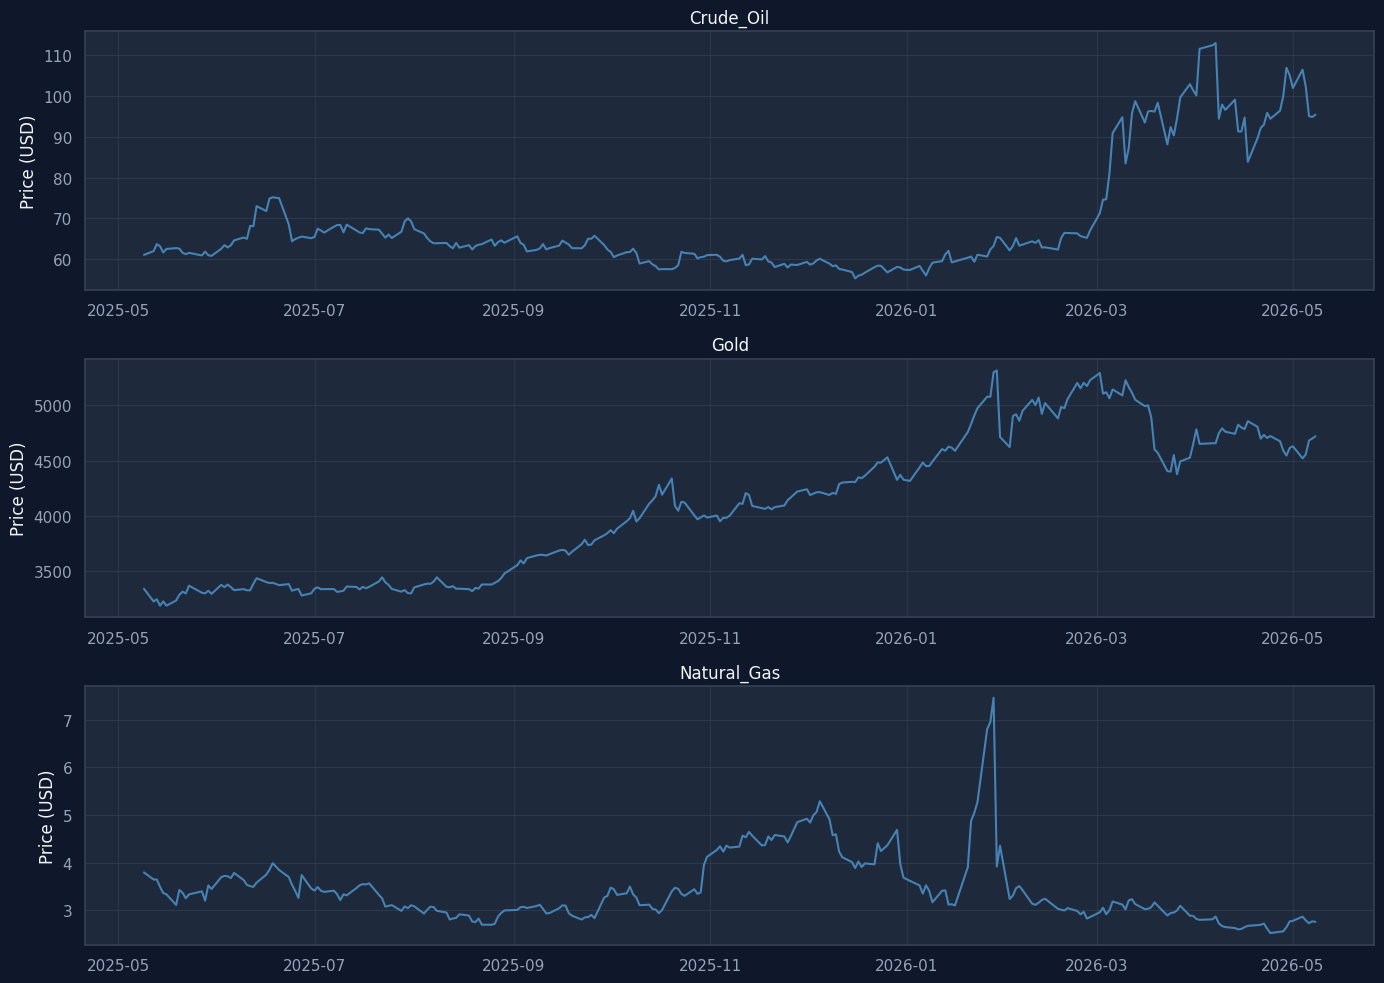

In [42]:
%matplotlib inline

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for ax, col in zip(axes, df.columns):
    ax.plot(df.index, df[col], linewidth=1.5, color='steelblue')
    ax.set_title(col)
    ax.set_ylabel('Price (USD)')
    ax.grid(True)

plt.tight_layout()
plt.show()

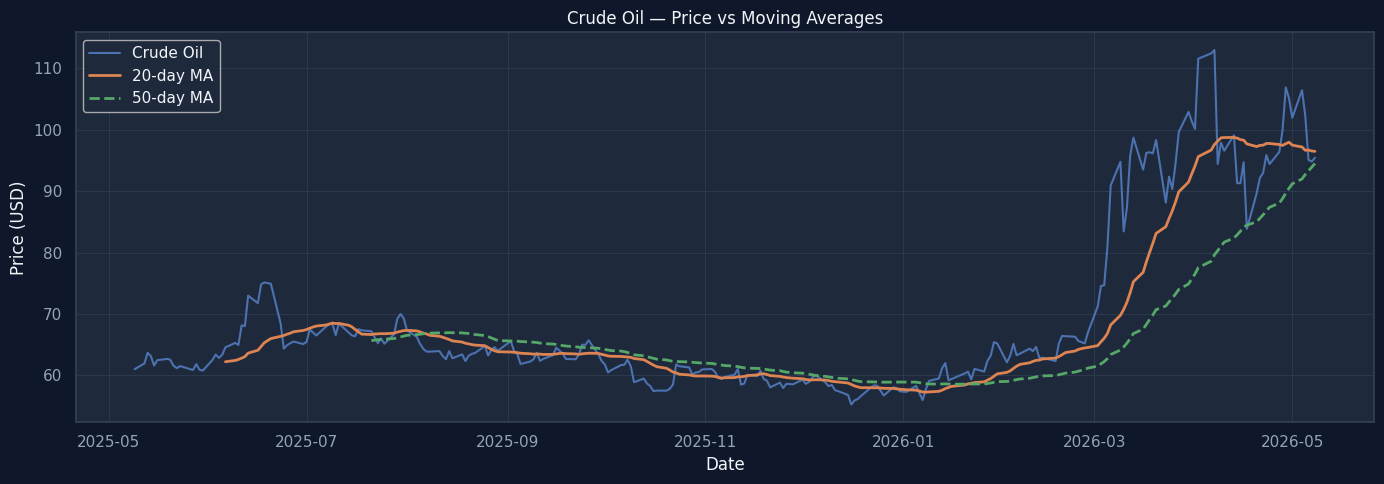

In [43]:
plt.figure(figsize=(14, 5))
plt.plot(df['Crude_Oil'],          label='Crude Oil',  linewidth=1.5)
plt.plot(df['Crude_Oil'].rolling(20).mean(), label='20-day MA', linewidth=2)
plt.plot(df['Crude_Oil'].rolling(50).mean(), label='50-day MA', linewidth=2, linestyle='--')
plt.title('Crude Oil — Price vs Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

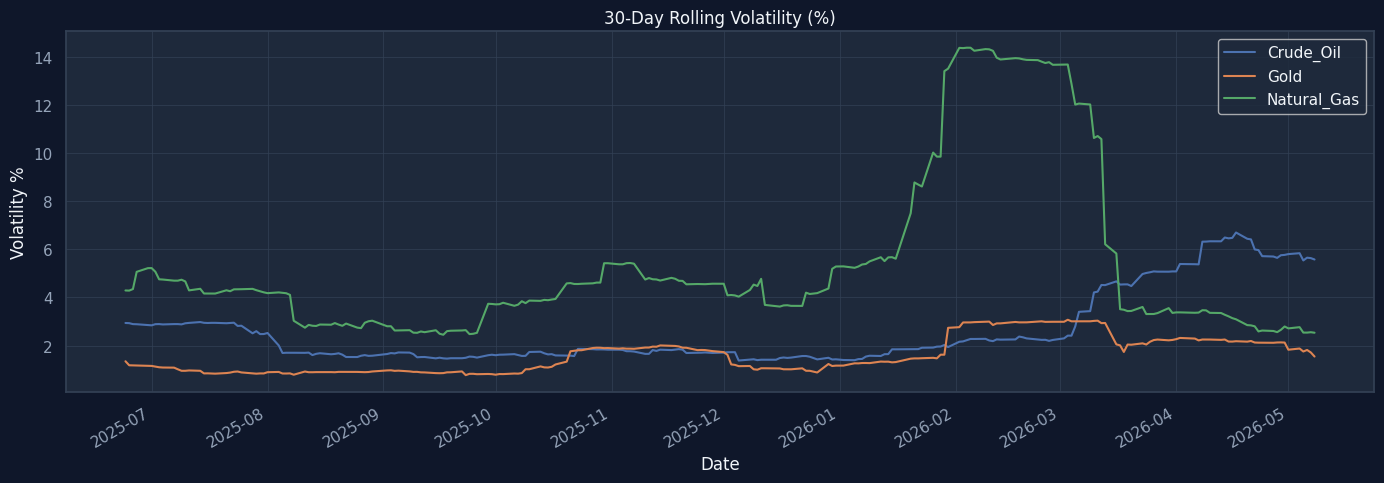

In [44]:
returns    = df.pct_change()
volatility = returns.rolling(30).std() * 100

volatility.plot(figsize=(14, 5), title='30-Day Rolling Volatility (%)')
plt.xlabel('Date')
plt.ylabel('Volatility %')
plt.grid(True)
plt.tight_layout()
plt.show()

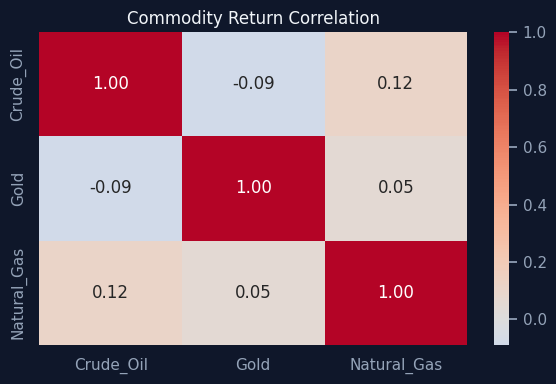

In [45]:
plt.figure(figsize=(6, 4))
sns.heatmap(returns.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Commodity Return Correlation')
plt.tight_layout()
plt.show()